# 02 — Preprocessing: Customer Churn Model

**Decisiones de diseño:**
- **Feature engineering v1.1**: lags (1-3), deltas, rolling stats, ratios de negocio
- **Split por cliente** (70/15/15) estratificado por churn_flag
- Fit del preprocessor exclusivamente sobre train (sin data leakage)
- Lags computados sobre el dataset completo antes del split (válido: split es por cliente, no por tiempo)


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RAW_PATH       = '../data/raw/customer_churn_simulated.csv'
PROCESSED_PATH = '../data/processed/'
REGISTRY_PATH  = '../models/registry/'
FIGURES_PATH   = '../artifacts/figures/'

for path in [PROCESSED_PATH, REGISTRY_PATH, FIGURES_PATH]:
    os.makedirs(path, exist_ok=True)

ID_COL     = 'customer_id'
PERIOD_COL = 'period'
TARGET_COL = 'churn'
RANDOM_STATE = 42

# Features base (se extiende en la celda de Feature Engineering)
NUM_COLS_BASE = [
    'tenure_months', 'age', 'monthly_charges', 'usage_minutes',
    'support_calls', 'complaints_last_3m', 'late_payments',
    'marketing_emails_opened', 'active_days_last_month'
]
NUM_COLS = NUM_COLS_BASE.copy()  # se actualizará con engineered features
CAT_COLS     = ['region', 'contract_type', 'payment_method']
FEATURE_COLS = NUM_COLS + CAT_COLS

print('Setup completo.')


Setup completo.


## 2. Carga y preparación base

In [2]:
df = pd.read_csv(RAW_PATH, parse_dates=[PERIOD_COL])
print(f'Shape original: {df.shape}')

# Ordenar por cliente y período — crítico para consistencia del panel
df = df.sort_values([ID_COL, PERIOD_COL]).reset_index(drop=True)

# Separar features e identificadores
FEATURE_COLS = NUM_COLS + CAT_COLS

print(f'Features: {len(FEATURE_COLS)} ({len(NUM_COLS)} numéricas + {len(CAT_COLS)} categóricas)')
print(f'Target  : {TARGET_COL}')
df.head()

Shape original: (480000, 15)
Features: 12 (9 numéricas + 3 categóricas)
Target  : churn


,customer_id,period,tenure_months,age,monthly_charges,usage_minutes,support_calls,complaints_last_3m,late_payments,marketing_emails_opened,active_days_last_month,region,contract_type,payment_method,churn
0,C0000001,2023-01-01,1,42,59.63,345.1,1,0,0,8,14,Lima,Monthly,Debit,0
1,C0000001,2023-02-01,2,42,54.73,289.4,2,0,0,2,22,Lima,Monthly,Debit,0
2,C0000001,2023-03-01,3,42,61.51,230.0,0,0,1,7,23,Lima,Monthly,Debit,0
3,C0000001,2023-04-01,4,42,53.77,225.9,1,1,0,3,25,Lima,Monthly,Debit,0
4,C0000001,2023-05-01,5,42,57.69,337.8,2,0,0,1,19,Lima,Monthly,Debit,0


## 2.5 Feature Engineering — Lags, Deltas, Rolling, Ratios

In [3]:
# ──────────────────────────────────────────────────────
# FEATURE ENGINEERING
# Computado antes del split: válido porque el split es
# por cliente (no por tiempo) → no hay data leakage.
# ──────────────────────────────────────────────────────

# --- 1. LAG VARIABLES ---
# Qué pasó 1/2/3 meses antes para cada cliente
LAG_COLS = ['monthly_charges', 'usage_minutes', 'support_calls',
            'active_days_last_month', 'complaints_last_3m']
LAG_PERIODS = [1, 2, 3]

for col in LAG_COLS:
    for lag in LAG_PERIODS:
        new_col = f'{col}_lag{lag}'
        df[new_col] = df.groupby(ID_COL)[col].shift(lag)
        # Primeras filas sin historial → bfill dentro del cliente
        df[new_col] = df.groupby(ID_COL)[new_col].transform(lambda x: x.bfill())

# --- 2. DELTA VARIABLES (cambio mes a mes) ---
DELTA_COLS = ['monthly_charges', 'usage_minutes', 'support_calls', 'active_days_last_month']
for col in DELTA_COLS:
    df[f'{col}_delta1'] = df[col] - df[f'{col}_lag1']

# --- 3. ROLLING STATISTICS (últimos 3 meses, usando shift para no incluir mes actual) ---
ROLL_COLS = ['monthly_charges', 'usage_minutes', 'support_calls']
for col in ROLL_COLS:
    df[f'{col}_roll3_mean'] = (
        df.groupby(ID_COL)[col]
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )
    df[f'{col}_roll3_std'] = (
        df.groupby(ID_COL)[col]
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std().fillna(0))
    )

# --- 4. RATIOS / VARIABLES COMBINADAS ---
df['charges_per_active_day'] = df['monthly_charges'] / (df['active_days_last_month'] + 1)
df['support_intensity']      = df['support_calls']   / (df['tenure_months'] + 1)
df['late_payment_rate']      = df['late_payments']   / (df['tenure_months'] + 1)
df['complaint_intensity']    = df['complaints_last_3m'] / (df['tenure_months'] + 1)
df['email_engagement']       = df['marketing_emails_opened'] / (df['active_days_last_month'] + 1)

# --- 5. Actualizar listas de features ---
LAG_FEATURE_COLS   = [f'{c}_lag{l}' for c in LAG_COLS for l in LAG_PERIODS]
DELTA_FEATURE_COLS = [f'{c}_delta1' for c in DELTA_COLS]
ROLL_FEATURE_COLS  = [f'{c}_roll3_{s}' for c in ROLL_COLS for s in ['mean','std']]
RATIO_FEATURE_COLS = ['charges_per_active_day', 'support_intensity', 'late_payment_rate',
                      'complaint_intensity', 'email_engagement']

ENGINEERED_COLS = LAG_FEATURE_COLS + DELTA_FEATURE_COLS + ROLL_FEATURE_COLS + RATIO_FEATURE_COLS

# Extender NUM_COLS y FEATURE_COLS
NUM_COLS     = NUM_COLS_BASE + ENGINEERED_COLS
FEATURE_COLS = NUM_COLS + CAT_COLS

print(f'Features base     : {len(NUM_COLS_BASE)} numéricas + {len(CAT_COLS)} categóricas')
print(f'Features nuevas   : {len(ENGINEERED_COLS)}')
print(f'  - Lags          : {len(LAG_FEATURE_COLS)}')
print(f'  - Deltas        : {len(DELTA_FEATURE_COLS)}')
print(f'  - Rolling       : {len(ROLL_FEATURE_COLS)}')
print(f'  - Ratios        : {len(RATIO_FEATURE_COLS)}')
print(f'Total FEATURE_COLS: {len(FEATURE_COLS)}')
print(f'NaN tras FE       : {df[ENGINEERED_COLS].isna().sum().sum()}')

# ──────────────────────────────────────────────────────────────────
# RFM + FEATURES ADICIONALES
# ──────────────────────────────────────────────────────────────────

# ─── R: RECENCY — meses desde la última señal de alerta ───────────
def months_since_last_event(series):
    """Meses desde la última vez que la serie fue > 0 (por cliente)."""
    result, count = [], 0
    for val in series:
        if val > 0:
            count = 0
        else:
            count += 1
        result.append(count)
    return result

df['recency_complaint']     = df.groupby(ID_COL)['complaints_last_3m'].transform(months_since_last_event)
df['recency_support_call']  = df.groupby(ID_COL)['support_calls'].transform(months_since_last_event)
df['recency_late_payment']  = df.groupby(ID_COL)['late_payments'].transform(months_since_last_event)
df['recency_low_activity']  = df.groupby(ID_COL)['active_days_last_month'].transform(
    lambda x: months_since_last_event((x < 10).astype(int)))

# ─── F: FREQUENCY — acumulado de eventos en vida del cliente ───────
df['freq_support_lifetime']      = df.groupby(ID_COL)['support_calls'].cumsum()
df['freq_complaints_lifetime']   = df.groupby(ID_COL)['complaints_last_3m'].cumsum()
df['freq_late_pay_lifetime']     = df.groupby(ID_COL)['late_payments'].cumsum()

# Meses con al menos 1 queja / soporte en últimos 6 meses
df['freq_complaint_months_6m'] = df.groupby(ID_COL)['complaints_last_3m'].transform(
    lambda x: (x > 0).rolling(6, min_periods=1).sum())
df['freq_support_months_6m']   = df.groupby(ID_COL)['support_calls'].transform(
    lambda x: (x > 0).rolling(6, min_periods=1).sum())

# ─── M: MONETARY — valor acumulado del cliente ────────────────────
df['monetary_charges_lifetime'] = df.groupby(ID_COL)['monthly_charges'].cumsum()
df['monetary_avg_charges_6m']   = df.groupby(ID_COL)['monthly_charges'].transform(
    lambda x: x.rolling(6, min_periods=1).mean())
# Proxy de CLV histórico: cargos acumulados / tenure
df['monetary_clv_ratio'] = df['monetary_charges_lifetime'] / (df['tenure_months'] + 1)

# ─── EWMA — más peso a meses recientes que rolling simple ─────────
EWMA_COLS = ['monthly_charges', 'usage_minutes', 'support_calls', 'active_days_last_month']
for col in EWMA_COLS:
    df[f'{col}_ewma3'] = df.groupby(ID_COL)[col].transform(
        lambda x: x.shift(1).ewm(span=3, min_periods=1).mean().fillna(x.iloc[0]))

# ─── TENDENCIA — pendiente lineal últimos 3 meses ─────────────────
def linear_slope(series, window=3):
    """Pendiente de regresión lineal sobre ventana deslizante."""
    import numpy as np
    x = np.arange(window)
    result = []
    vals = series.values
    for i in range(len(vals)):
        start = max(0, i - window + 1)
        y = vals[start:i+1]
        if len(y) < 2:
            result.append(0.0)
        else:
            xi = np.arange(len(y))
            slope = np.polyfit(xi, y, 1)[0]
            result.append(slope)
    return result

TREND_COLS = ['monthly_charges', 'usage_minutes', 'support_calls']
for col in TREND_COLS:
    df[f'{col}_trend3'] = df.groupby(ID_COL)[col].transform(linear_slope)

# ─── INTERACCIONES ────────────────────────────────────────────────
df['support_x_complaint']    = df['support_calls'] * df['complaints_last_3m']
df['late_pay_x_charges']     = df['late_payments'] * df['monthly_charges']
df['inactivity_x_support']   = (31 - df['active_days_last_month']) * df['support_calls']

# ─── Actualizar listas de features ───────────────────────────────
RFM_COLS = [
    'recency_complaint', 'recency_support_call', 'recency_late_payment', 'recency_low_activity',
    'freq_support_lifetime', 'freq_complaints_lifetime', 'freq_late_pay_lifetime',
    'freq_complaint_months_6m', 'freq_support_months_6m',
    'monetary_charges_lifetime', 'monetary_avg_charges_6m', 'monetary_clv_ratio',
]
EWMA_FEATURE_COLS   = [f'{c}_ewma3' for c in EWMA_COLS]
TREND_FEATURE_COLS  = [f'{c}_trend3' for c in TREND_COLS]
INTERACT_COLS       = ['support_x_complaint', 'late_pay_x_charges', 'inactivity_x_support']

NEW_COLS = RFM_COLS + EWMA_FEATURE_COLS + TREND_FEATURE_COLS + INTERACT_COLS

# Limpiar NaN
for col in NEW_COLS:
    df[col] = df.groupby(ID_COL)[col].transform(
        lambda x: x.ffill().bfill().fillna(0))

ENGINEERED_COLS = ENGINEERED_COLS + NEW_COLS
NUM_COLS        = NUM_COLS_BASE + ENGINEERED_COLS
FEATURE_COLS    = NUM_COLS + CAT_COLS

print(f'\n=== FEATURE ENGINEERING TOTAL ===')
print(f'  Base              : {len(NUM_COLS_BASE)}')
print(f'  Lags              : {len(LAG_FEATURE_COLS)}')
print(f'  Deltas            : {len(DELTA_FEATURE_COLS)}')
print(f'  Rolling           : {len(ROLL_FEATURE_COLS)}')
print(f'  Ratios            : {len(RATIO_FEATURE_COLS)}')
print(f'  RFM               : {len(RFM_COLS)}')
print(f'  EWMA              : {len(EWMA_FEATURE_COLS)}')
print(f'  Tendencia         : {len(TREND_FEATURE_COLS)}')
print(f'  Interacciones     : {len(INTERACT_COLS)}')
print(f'  Categóricas OH    : ~{len(CAT_COLS)*3} (estimado post-encoding)')
print(f'  TOTAL FEATURE_COLS: {len(FEATURE_COLS)}')
print(f'  NaN en nuevas FE  : {df[NEW_COLS].isna().sum().sum()}')

# --- 7. Limpieza de NaN residuales — cobertura total ────────────
# ffill → bfill → fillna(0) cubre: primeras filas, clientes con 1 período, rolling NaN
for col in ENGINEERED_COLS:
    df[col] = df.groupby(ID_COL)[col].transform(
        lambda x: x.ffill().bfill().fillna(0)
    )

print(f'NaN residuales totales: {df[ENGINEERED_COLS].isna().sum().sum()}')

# ══════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING v1.2 — Alarmas, Streaks, Features de Riesgo
# ══════════════════════════════════════════════════════════════════

# --- 9. BINARY ALARM FLAGS ---
df['alarm_high_support']  = (df['support_calls'] >= 3).astype(int)
df['alarm_has_complaint'] = (df['complaints_last_3m'] > 0).astype(int)
df['alarm_late_payment']  = (df['late_payments'] > 0).astype(int)
df['alarm_low_activity']  = (df['active_days_last_month'] < 10).astype(int)
df['alarm_charging_up']   = (df['monthly_charges_delta1'] > 0).astype(int)

# --- 10. CONSECUTIVE STREAKS ---
def consecutive_streak(binary_series):
    result, count = [], 0
    for v in binary_series:
        if v == 1:
            count += 1
        else:
            count = 0
        result.append(count)
    return result

df['streak_support']   = df.groupby(ID_COL)['alarm_high_support'].transform(consecutive_streak)
df['streak_complaint'] = df.groupby(ID_COL)['alarm_has_complaint'].transform(consecutive_streak)
df['streak_late_pay']  = df.groupby(ID_COL)['alarm_late_payment'].transform(consecutive_streak)
df['streak_low_act']   = df.groupby(ID_COL)['alarm_low_activity'].transform(consecutive_streak)

# --- 11. COMPOSITE RISK ---
df['composite_risk']   = (df['alarm_high_support'] + df['alarm_has_complaint'] +
                           df['alarm_late_payment'] + df['alarm_low_activity'])
df['composite_streak'] = (df['streak_support'] + df['streak_complaint'] +
                           df['streak_late_pay'] + df['streak_low_act'])

# --- 12. RECENT vs HISTORICAL RATE ---
eps = 1e-6
df['support_recent_vs_hist']   = (
    df.groupby(ID_COL)['support_calls'].transform(lambda x: x.rolling(3, min_periods=1).mean()) /
    (df.groupby(ID_COL)['support_calls'].transform('mean') + eps))
df['complaint_recent_vs_hist'] = (
    df.groupby(ID_COL)['complaints_last_3m'].transform(lambda x: x.rolling(3, min_periods=1).mean()) /
    (df.groupby(ID_COL)['complaints_last_3m'].transform('mean') + eps))
df['activity_recent_vs_hist']  = (
    df.groupby(ID_COL)['active_days_last_month'].transform(lambda x: x.rolling(3, min_periods=1).mean()) /
    (df.groupby(ID_COL)['active_days_last_month'].transform('mean') + eps))

# --- 13. RELATIVE CHARGE INCREASE ---
df['charges_relative_increase'] = (df['monthly_charges_delta1'] / (df['monthly_charges_lag1'] + eps)).clip(-2, 2)

# --- Actualizar listas ---
ALARM_COLS     = ['alarm_high_support','alarm_has_complaint','alarm_late_payment',
                  'alarm_low_activity','alarm_charging_up']
STREAK_COLS    = ['streak_support','streak_complaint','streak_late_pay','streak_low_act']
COMPOSITE_COLS = ['composite_risk','composite_streak']
RATE_COLS      = ['support_recent_vs_hist','complaint_recent_vs_hist',
                  'activity_recent_vs_hist','charges_relative_increase']
V12_COLS = ALARM_COLS + STREAK_COLS + COMPOSITE_COLS + RATE_COLS

for col in V12_COLS:
    df[col] = df.groupby(ID_COL)[col].transform(lambda x: x.ffill().bfill().fillna(0))

ENGINEERED_COLS = ENGINEERED_COLS + V12_COLS
NUM_COLS        = NUM_COLS_BASE + ENGINEERED_COLS
FEATURE_COLS    = NUM_COLS + CAT_COLS

print(f'\n=== FE v1.2 — nuevas features ===')
print(f'  Alarmas binarias     : {len(ALARM_COLS)}')
print(f'  Streaks consecutivos : {len(STREAK_COLS)}')
print(f'  Composite risk       : {len(COMPOSITE_COLS)}')
print(f'  Rates reciente/hist  : {len(RATE_COLS)}')
print(f'  TOTAL FEATURE_COLS   : {len(FEATURE_COLS)}')
print(f'  NaN en v1.2 cols     : {df[V12_COLS].isna().sum().sum()}')


Features base     : 9 numéricas + 3 categóricas
Features nuevas   : 30
  - Lags          : 15
  - Deltas        : 4
  - Rolling       : 6
  - Ratios        : 5
Total FEATURE_COLS: 42
NaN tras FE       : 407474



=== FEATURE ENGINEERING TOTAL ===
  Base              : 9
  Lags              : 15
  Deltas            : 4
  Rolling           : 6
  Ratios            : 5
  RFM               : 12
  EWMA              : 4
  Tendencia         : 3
  Interacciones     : 3
  Categóricas OH    : ~9 (estimado post-encoding)
  TOTAL FEATURE_COLS: 64
  NaN en nuevas FE  : 0


NaN residuales totales: 0



=== FE v1.2 — nuevas features ===
  Alarmas binarias     : 5
  Streaks consecutivos : 4
  Composite risk       : 2
  Rates reciente/hist  : 4
  TOTAL FEATURE_COLS   : 79
  NaN en v1.2 cols     : 0


## 3. Target Shift + Split Temporal

**Target**: en producción puntuamos el mes T para predecir si el cliente fuga en T+1.  
Por lo tanto `churn_next_month = churn.shift(-1)` agrupado por cliente.  
La última fila de cada cliente queda NaN y se descarta.

**Split** (cortes fijos por período, sin overlap):
| Dataset | Período | Uso |
|---------|---------|-----|
| Train | 2023-01 → 2025-06 | entrenamiento |
| Validation | 2025-07 → 2025-12 | tuning |
| Test | 2026-01 → 2026-06 | evaluación |
| OOT | 2026-07 → 2026-12 | producción simulada |

In [4]:
# ── 1. TARGET SHIFT: predecimos fuga del mes SIGUIENTE ──────────
# Churn=1 en el mes T → la señal debe estar en T-1 (mes previo a la fuga)
# shift(-1) dentro de cada cliente: la fila T-1 recibe target=1
# La última fila de cada cliente queda NaN → se descarta
df['churn_next_month'] = df.groupby(ID_COL)[TARGET_COL].shift(-1)

rows_before = len(df)
df = df.dropna(subset=['churn_next_month']).copy()
df['churn_next_month'] = df['churn_next_month'].astype(int)
TARGET_COL = 'churn_next_month'   # actualizar referencia global

print(f'Filas antes del drop : {rows_before:,}')
print(f'Filas después del drop: {len(df):,}  (eliminadas: {rows_before - len(df):,} — última obs de cada cliente)')
print(f'Positivos (churn next): {df[TARGET_COL].sum():,}  ({df[TARGET_COL].mean()*100:.2f}%)')

# ── 2. SPLIT TEMPORAL (cortes fijos por período) ──────────────────
TRAIN_END  = '2025-06-01'
VAL_START  = '2025-07-01';  VAL_END  = '2025-12-01'
TEST_START = '2026-01-01';  TEST_END = '2026-06-01'
OOT_START  = '2026-07-01';  OOT_END  = '2026-12-01'

train_df = df[df[PERIOD_COL] <= TRAIN_END].copy()
val_df   = df[(df[PERIOD_COL] >= VAL_START)  & (df[PERIOD_COL] <= VAL_END)].copy()
test_df  = df[(df[PERIOD_COL] >= TEST_START) & (df[PERIOD_COL] <= TEST_END)].copy()
oot_df   = df[(df[PERIOD_COL] >= OOT_START)  & (df[PERIOD_COL] <= OOT_END)].copy()

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df), ('OOT', oot_df)]:
    print(f'{name:<6}: {len(split):>7,} obs | '
          f'{split[ID_COL].nunique():>5,} clientes | '
          f'churn rate: {split[TARGET_COL].mean()*100:.2f}% | '
          f'período: {split[PERIOD_COL].min().strftime("%Y-%m")} → {split[PERIOD_COL].max().strftime("%Y-%m")}')

# Verificar sin solapamiento de períodos
assert train_df[PERIOD_COL].max() < val_df[PERIOD_COL].min(), 'OVERLAP train/val'
assert val_df[PERIOD_COL].max()   < test_df[PERIOD_COL].min(), 'OVERLAP val/test'
assert test_df[PERIOD_COL].max()  < oot_df[PERIOD_COL].min(),  'OVERLAP test/oot'
print('\n✓ Sin solapamiento temporal entre splits')

Filas antes del drop : 480,000
Filas después del drop: 428,755  (eliminadas: 51,245 — última obs de cada cliente)
Positivos (churn next): 37,823  (8.82%)
Train : 273,779 obs | 32,337 clientes | churn rate: 8.76% | período: 2023-01 → 2025-06
Val   :  54,784 obs | 13,088 clientes | churn rate: 8.77% | período: 2025-07 → 2025-12
Test  :  54,677 obs | 13,229 clientes | churn rate: 8.91% | período: 2026-01 → 2026-06
OOT   :  45,515 obs | 12,454 clientes | churn rate: 9.17% | período: 2026-07 → 2026-11

✓ Sin solapamiento temporal entre splits


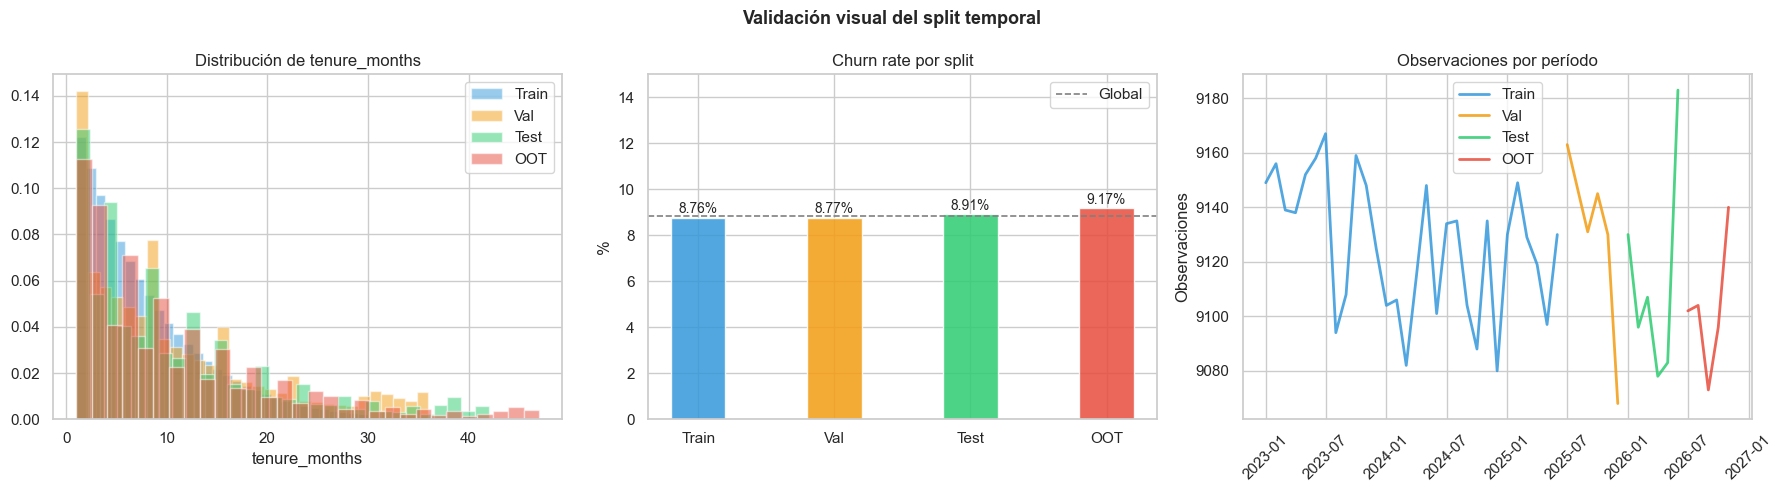

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
split_data = [
    ('Train', train_df, '#3498db'),
    ('Val',   val_df,   '#f39c12'),
    ('Test',  test_df,  '#2ecc71'),
    ('OOT',   oot_df,   '#e74c3c'),
]

# Distribución de tenure por split
for name, subset, color in split_data:
    axes[0].hist(subset['tenure_months'], bins=30, alpha=0.5, color=color, label=name, density=True)
axes[0].set_title('Distribución de tenure_months')
axes[0].set_xlabel('tenure_months')
axes[0].legend()

# Churn rate por split
names  = [s[0] for s in split_data]
rates  = [s[1][TARGET_COL].mean()*100 for s in split_data]
colors = [s[2] for s in split_data]
bars = axes[1].bar(names, rates, color=colors, alpha=0.85, edgecolor='white', width=0.4)
axes[1].axhline(df[TARGET_COL].mean()*100, color='gray', linestyle='--', linewidth=1.2, label='Global')
axes[1].set_title('Churn rate por split')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 15)
axes[1].legend()
for bar, v in zip(bars, rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{v:.2f}%', ha='center', fontsize=10)

# Observaciones por período coloreadas por split
for name, subset, color in split_data:
    tc = subset.groupby(PERIOD_COL).size()
    axes[2].plot(tc.index, tc.values, color=color, label=name, linewidth=2, alpha=0.85)
axes[2].set_title('Observaciones por período')
axes[2].set_ylabel('Observaciones')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.suptitle('Validación visual del split temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}temporal_split_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET_COL].copy()

X_test  = test_df[FEATURE_COLS].copy()
y_test  = test_df[TARGET_COL].copy()

X_oot   = oot_df[FEATURE_COLS].copy()
y_oot   = oot_df[TARGET_COL].copy()

for name, X, y in [('Train', X_train, y_train), ('Val', X_val, y_val),
                    ('Test',  X_test,  y_test),  ('OOT', X_oot, y_oot)]:
    print(f'{name:<6}: {X.shape}  | positivos: {y.sum():,} ({y.mean()*100:.2f}%)')

Train : (273779, 79)  | positivos: 23,974 (8.76%)
Val   : (54784, 79)  | positivos: 4,803 (8.77%)
Test  : (54677, 79)  | positivos: 4,873 (8.91%)
OOT   : (45515, 79)  | positivos: 4,173 (9.17%)


## 4. Transformación (encoding + scaling)


In [7]:
# Pipeline de transformación
# TargetEncoder: fit SOLO sobre train con cross-val interna → no data leakage
from sklearn.preprocessing import TargetEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_COLS),
        ('cat', TargetEncoder(target_type='binary', smooth='auto', random_state=RANDOM_STATE), CAT_COLS)
    ],
    remainder='drop'
)

X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
X_oot_proc   = preprocessor.transform(X_oot)

feature_names = NUM_COLS + CAT_COLS

print(f'Features después del encoding: {len(feature_names)}')
print(f'  Numéricas (scaled)  : {len(NUM_COLS)}')
print(f'  Categóricas (TE)    : {len(CAT_COLS)}')
print(f'  X_train_proc        : {X_train_proc.shape}')
print(f'  X_val_proc          : {X_val_proc.shape}')
print(f'  X_test_proc         : {X_test_proc.shape}')
print(f'  X_oot_proc          : {X_oot_proc.shape}')

# Target encodings aprendidos
te = preprocessor.named_transformers_['cat']
print('\nTarget encoding aprendido (P(churn_next_month) por categoría):')
for col_idx, col in enumerate(CAT_COLS):
    cats = te.categories_[col_idx]
    encs = te.encodings_[col_idx]
    print(f'  {col}:')
    for cat, enc in sorted(zip(cats, encs), key=lambda x: -x[1]):
        print(f'    {cat:20s}: {enc:.4f}')

Features después del encoding: 79
  Numéricas (scaled)  : 76
  Categóricas (TE)    : 3
  X_train_proc        : (273779, 79)
  X_val_proc          : (54784, 79)
  X_test_proc         : (54677, 79)
  X_oot_proc          : (45515, 79)

Target encoding aprendido (P(churn_next_month) por categoría):
  region:
    East                : 0.0886
    South               : 0.0882
    North               : 0.0880
    Lima                : 0.0869
    International       : 0.0858
  contract_type:
    Monthly             : 0.1010
    Premium             : 0.0998
    Enterprise          : 0.0754
    Annual              : 0.0744
  payment_method:
    CreditCard          : 0.0880
    Cash                : 0.0880
    Debit               : 0.0871
    DigitalWallet       : 0.0870


## 5. Validación de drift


In [8]:
print('=== DRIFT CHECK ===')

# 1. Churn rate por split
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test), ('OOT', y_oot)]:
    print(f'  {name} churn rate: {y.mean()*100:.2f}%')

# 2. Tenure por split (con split temporal, tenure aumenta naturalmente con el tiempo)
print()
print('  Tenure medio por split:')
for name, subset in [('Train', train_df), ('Val', val_df), ('Test', test_df), ('OOT', oot_df)]:
    t = subset['tenure_months']
    print(f'    {name}: mean={t.mean():.1f}  std={t.std():.1f}  min={t.min()}  max={t.max()}')

# 3. Feature drift (medias escaladas)
print()
train_proc_df = pd.DataFrame(X_train_proc, columns=feature_names)
val_proc_df   = pd.DataFrame(X_val_proc,   columns=feature_names)
test_proc_df  = pd.DataFrame(X_test_proc,  columns=feature_names)
oot_proc_df   = pd.DataFrame(X_oot_proc,   columns=feature_names)

drift_df = pd.DataFrame({
    'train_mean': train_proc_df[NUM_COLS].mean().round(3),
    'val_mean'  : val_proc_df[NUM_COLS].mean().round(3),
    'test_mean' : test_proc_df[NUM_COLS].mean().round(3),
    'oot_mean'  : oot_proc_df[NUM_COLS].mean().round(3),
})
drift_df['max_drift'] = (drift_df[['val_mean','test_mean','oot_mean']]
                          .sub(drift_df['train_mean'], axis=0).abs().max(axis=1).round(3))
drift_df = drift_df.sort_values('max_drift', ascending=False)
print('  Feature drift (diferencia de medias escaladas vs train):')
print(drift_df.to_string())
print()

high_drift = drift_df[drift_df['max_drift'] > 0.3]
if len(high_drift) > 0:
    print(f'⚠ Features con drift > 0.3 (esperado en split temporal para vars acumuladas): {list(high_drift.index)}')
else:
    print('✓ Sin drift significativo entre splits (max_drift < 0.3)')

# 4. Verificar sin solapamiento TEMPORAL (no de clientes — con split temporal sí hay overlap de clientes)
assert train_df[PERIOD_COL].max() < val_df[PERIOD_COL].min(), 'OVERLAP temporal train/val'
assert val_df[PERIOD_COL].max()   < test_df[PERIOD_COL].min(), 'OVERLAP temporal val/test'
assert test_df[PERIOD_COL].max()  < oot_df[PERIOD_COL].min(),  'OVERLAP temporal test/oot'
print('✓ Sin solapamiento temporal entre splits')


=== DRIFT CHECK ===
  Train churn rate: 8.76%
  Val churn rate: 8.77%
  Test churn rate: 8.91%
  OOT churn rate: 9.17%

  Tenure medio por split:
    Train: mean=7.6  std=6.2  min=1  max=30
    Val: mean=10.6  std=8.9  min=1  max=36
    Test: mean=10.8  std=9.5  min=1  max=42
    OOT: mean=10.8  std=9.8  min=1  max=47

  Feature drift (diferencia de medias escaladas vs train):
                               train_mean  val_mean  test_mean  oot_mean  max_drift
freq_late_pay_lifetime               -0.0     0.528      0.592     0.618      0.618
tenure_months                         0.0     0.490      0.520     0.523      0.523
freq_support_lifetime                 0.0     0.437      0.475     0.484      0.484
monetary_charges_lifetime            -0.0     0.449      0.471     0.478      0.478
recency_low_activity                 -0.0     0.405      0.413     0.409      0.413
freq_complaints_lifetime              0.0     0.365      0.399     0.410      0.410
streak_late_pay                 

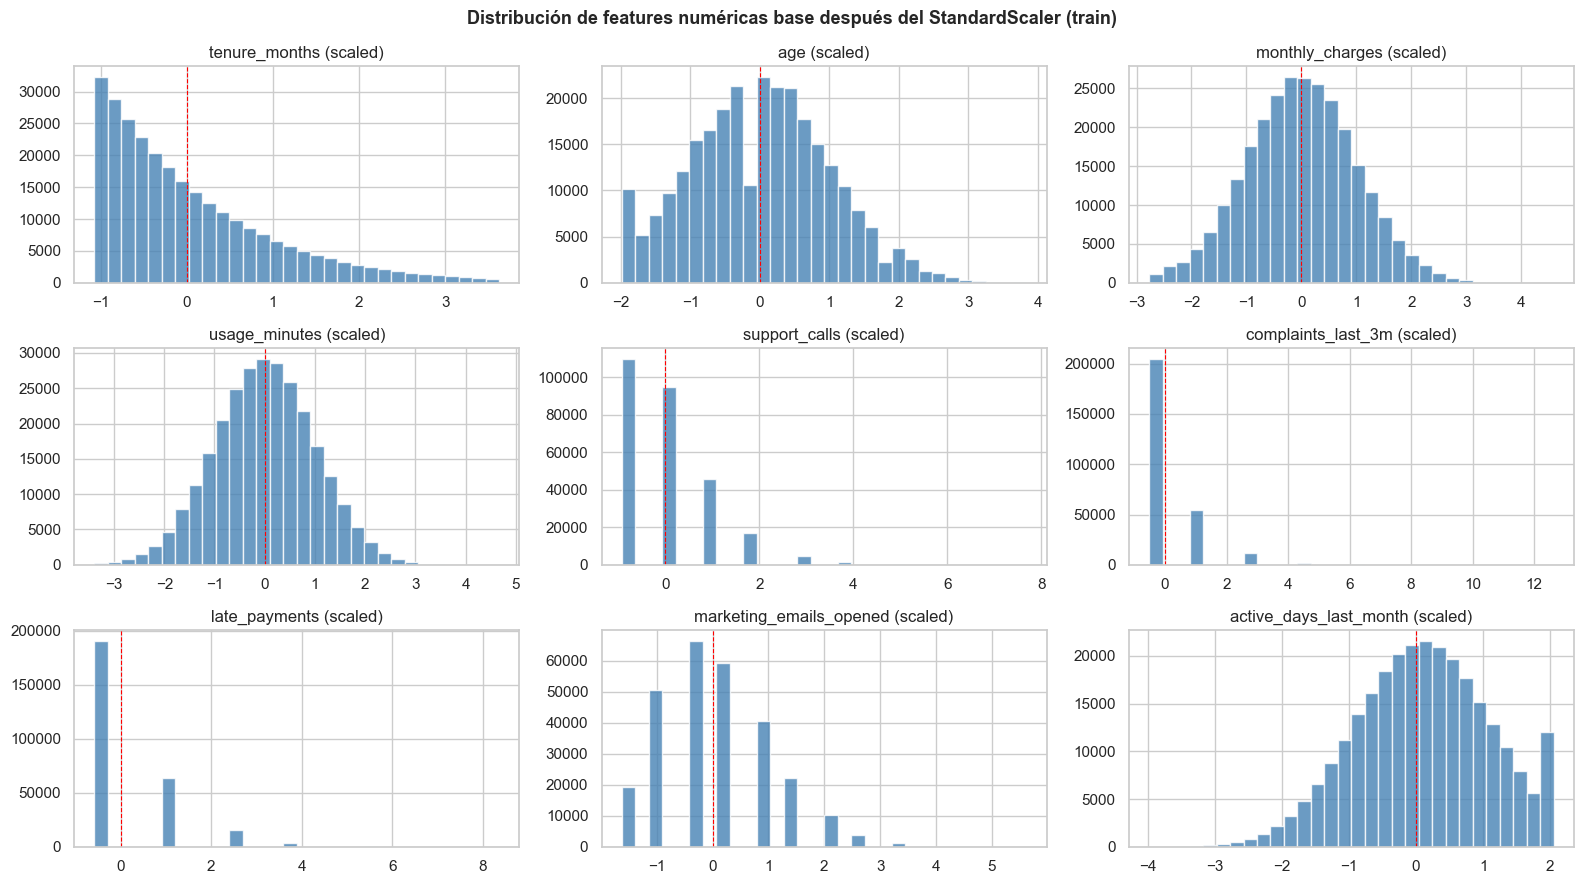

In [9]:
# Distribución de features tras el scaling — primeras 9 numéricas base
train_proc_df = pd.DataFrame(X_train_proc, columns=feature_names)

plot_cols = NUM_COLS_BASE  # solo las 9 originales para legibilidad
n = len(plot_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    axes[i].hist(train_proc_df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} (scaled)')
    axes[i].axvline(0, color='red', linestyle='--', linewidth=0.8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features numéricas base después del StandardScaler (train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}scaled_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Guardado de artefactos


In [10]:
np.save(f'{PROCESSED_PATH}X_train.npy', X_train_proc)
np.save(f'{PROCESSED_PATH}X_val.npy',   X_val_proc)
np.save(f'{PROCESSED_PATH}X_test.npy',  X_test_proc)
np.save(f'{PROCESSED_PATH}X_oot.npy',   X_oot_proc)

y_train.reset_index(drop=True).to_csv(f'{PROCESSED_PATH}y_train.csv', index=False)
y_val.reset_index(drop=True).to_csv(f'{PROCESSED_PATH}y_val.csv',     index=False)
y_test.reset_index(drop=True).to_csv(f'{PROCESSED_PATH}y_test.csv',   index=False)
y_oot.reset_index(drop=True).to_csv(f'{PROCESSED_PATH}y_oot.csv',     index=False)

# Guardar períodos de cada split (necesarios en notebook 04 para análisis mensual)
train_df[[ID_COL, PERIOD_COL]].reset_index(drop=True).to_csv(f'{PROCESSED_PATH}train_index.csv', index=False)
val_df[[ID_COL, PERIOD_COL]].reset_index(drop=True).to_csv(f'{PROCESSED_PATH}val_index.csv',     index=False)
test_df[[ID_COL, PERIOD_COL]].reset_index(drop=True).to_csv(f'{PROCESSED_PATH}test_index.csv',   index=False)
oot_df[[ID_COL, PERIOD_COL]].reset_index(drop=True).to_csv(f'{PROCESSED_PATH}oot_index.csv',     index=False)

with open(f'{PROCESSED_PATH}feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

joblib.dump(preprocessor, f'{REGISTRY_PATH}preprocessor_v1.pkl')

metadata = {
    'version'          : 'v2.0',
    'split_strategy'   : 'temporal',
    'target'           : 'churn_next_month',
    'train_period'     : '2023-01 → 2025-06',
    'val_period'       : '2025-07 → 2025-12',
    'test_period'      : '2026-01 → 2026-06',
    'oot_period'       : '2026-07 → 2026-12',
    'train_size'       : int(len(X_train_proc)),
    'val_size'         : int(len(X_val_proc)),
    'test_size'        : int(len(X_test_proc)),
    'oot_size'         : int(len(X_oot_proc)),
    'train_churn_rate' : float(round(y_train.mean(), 4)),
    'val_churn_rate'   : float(round(y_val.mean(), 4)),
    'test_churn_rate'  : float(round(y_test.mean(), 4)),
    'oot_churn_rate'   : float(round(y_oot.mean(), 4)),
    'n_features'       : len(feature_names),
    'num_cols'         : NUM_COLS,
    'cat_cols'         : CAT_COLS,
    'feature_names'    : feature_names,
    'encoding'         : 'TargetEncoder(smooth=auto)',
    'scaling'          : 'StandardScaler'
}

with open(f'{REGISTRY_PATH}preprocessing_metadata_v2.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artefactos guardados:')
print(f'  {PROCESSED_PATH}X_train/val/test/oot.npy')
print(f'  {PROCESSED_PATH}y_train/val/test/oot.csv')
print(f'  {PROCESSED_PATH}train/val/test/oot_index.csv')
print(f'  {REGISTRY_PATH}preprocessor_v1.pkl')
print(f'  {REGISTRY_PATH}preprocessing_metadata_v2.json')

Artefactos guardados:
  ../data/processed/X_train/val/test/oot.npy
  ../data/processed/y_train/val/test/oot.csv
  ../data/processed/train/val/test/oot_index.csv
  ../models/registry/preprocessor_v1.pkl
  ../models/registry/preprocessing_metadata_v2.json


In [11]:
print('=' * 60)
print('PREPROCESSING COMPLETO — v2.0 (split temporal + churn_next_month)')
print('=' * 60)
print(f'  Target    : churn_next_month (shift -1 por cliente)')
print(f'  Split     : temporal')
print(f'  Train : {X_train_proc.shape}  | churn {y_train.mean()*100:.2f}%  | 2023-01 → 2025-06')
print(f'  Val   : {X_val_proc.shape}    | churn {y_val.mean()*100:.2f}%  | 2025-07 → 2025-12')
print(f'  Test  : {X_test_proc.shape}   | churn {y_test.mean()*100:.2f}%  | 2026-01 → 2026-06')
print(f'  OOT   : {X_oot_proc.shape}    | churn {y_oot.mean()*100:.2f}%  | 2026-07 → 2026-12')
print(f'  Features : {len(feature_names)}')
print('=' * 60)
print('Listo para notebook 03_training.ipynb')


PREPROCESSING COMPLETO — v2.0 (split temporal + churn_next_month)
  Target    : churn_next_month (shift -1 por cliente)
  Split     : temporal
  Train : (273779, 79)  | churn 8.76%  | 2023-01 → 2025-06
  Val   : (54784, 79)    | churn 8.77%  | 2025-07 → 2025-12
  Test  : (54677, 79)   | churn 8.91%  | 2026-01 → 2026-06
  OOT   : (45515, 79)    | churn 9.17%  | 2026-07 → 2026-12
  Features : 79
Listo para notebook 03_training.ipynb
